# LHS sample for LLM ICC reliability check

Selects 50 blocks that cover morphology, density, functions, accessibility, and spatial position. `morphotype` is not used.

In [1]:
from pathlib import Path

import geopandas as gpd

data_path = Path("/Users/mvin/Code/paper_1/blocks_agg_with_indicators.geojson")

gdf = gpd.read_file(data_path)
gdf.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


LHS_FEATURES = [
    "log_site_area",
    "population_density",
    "fsi",
    "gsi",
    "l",
    "mxi",
    "residential",
    "business",
    "industrial",
    "area_accessibility",
]


def prepare_sampling_data(gdf):
    required = [
        "site_area",
        "population",
        "fsi",
        "gsi",
        "l",
        "mxi",
        "residential",
        "business",
        "industrial",
        "area_accessibility",
    ]
    missing = [col for col in required if col not in gdf.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    out = gdf.copy()
    for col in required:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["log_site_area"] = np.log1p(out["site_area"])
    out["population_density"] = np.where(
        out["site_area"] > 0,
        out["population"] / out["site_area"],
        np.nan,
    )

    valid = out.dropna(subset=LHS_FEATURES).copy()
    excluded = len(out) - len(valid)
    print(f"Rows excluded before LHS: {excluded} of {len(out)}")
    return out, valid, LHS_FEATURES


def _minmax(values):
    values = np.asarray(values, dtype=float)
    lo = np.nanmin(values, axis=0)
    hi = np.nanmax(values, axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    return (values - lo) / span


def _lhs_points(n, d, seed):
    rng = np.random.default_rng(seed)
    points = np.empty((n, d), dtype=float)
    for j in range(d):
        points[:, j] = (rng.permutation(n) + rng.random(n)) / n
    return points


def lhs_select_real_points(df, features, sample_size, seed):
    if len(df) < sample_size:
        raise ValueError(f"Need at least {sample_size} valid rows, got {len(df)}")

    real_points = _minmax(df[features].to_numpy(float))
    lhs_points = _lhs_points(sample_size, len(features), seed)
    selected = []
    used = set()

    for point in lhs_points:
        distances = np.linalg.norm(real_points - point, axis=1)
        for idx in np.argsort(distances):
            idx = int(idx)
            if idx not in used:
                used.add(idx)
                selected.append(idx)
                break

    return df.iloc[selected].copy()


def _ks_statistic(a, b):
    a = np.sort(pd.Series(a).dropna().to_numpy(float))
    b = np.sort(pd.Series(b).dropna().to_numpy(float))
    if len(a) == 0 or len(b) == 0:
        return np.nan
    values = np.sort(np.unique(np.concatenate([a, b])))
    cdf_a = np.searchsorted(a, values, side="right") / len(a)
    cdf_b = np.searchsorted(b, values, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


def _land_use_score(full_gdf, sample_gdf):
    if "land_use" not in full_gdf.columns or "land_use" not in sample_gdf.columns:
        return np.nan
    full = full_gdf["land_use"].astype(str).value_counts(normalize=True)
    sample = sample_gdf["land_use"].astype(str).value_counts(normalize=True)
    cats = full.index.union(sample.index)
    return float(0.5 * np.abs(full.reindex(cats, fill_value=0) - sample.reindex(cats, fill_value=0)).sum())


def _centroids_metric(gdf):
    if "geometry" not in gdf.columns:
        return None
    geo = gdf.dropna(subset=["geometry"])
    if geo.empty:
        return None
    if geo.crs is not None and geo.crs.is_geographic:
        geo = geo.to_crs(geo.estimate_utm_crs())
    centroids = geo.geometry.centroid
    return pd.DataFrame({"x": centroids.x, "y": centroids.y}, index=geo.index)


def _spatial_score(full_gdf, sample_gdf):
    full_xy = _centroids_metric(full_gdf)
    sample_xy = _centroids_metric(sample_gdf)
    if full_xy is None or sample_xy is None or sample_xy.empty:
        return np.nan

    full_values = full_xy.to_numpy(float)
    sample_values = sample_xy.to_numpy(float)
    distances = np.sqrt(((full_values[:, None, :] - sample_values[None, :, :]) ** 2).sum(axis=2))
    coverage = float(distances.min(axis=1).mean())
    diagonal = math.dist(full_values.min(axis=0), full_values.max(axis=0))
    return coverage / diagonal if diagonal > 0 else np.nan


def score_sample(full_gdf, sample_gdf, features):
    ks_by_feature = {
        feature: _ks_statistic(full_gdf[feature], sample_gdf[feature])
        for feature in features
    }
    distribution_score = float(np.nanmean(list(ks_by_feature.values())))
    land_use_score = _land_use_score(full_gdf, sample_gdf)
    spatial_score = _spatial_score(full_gdf, sample_gdf)

    total_score = distribution_score
    if np.isfinite(land_use_score):
        total_score += 0.3 * land_use_score
    if np.isfinite(spatial_score):
        total_score += 0.2 * spatial_score

    return {
        "total_score": float(total_score),
        "distribution_score": distribution_score,
        "land_use_score": None if not np.isfinite(land_use_score) else float(land_use_score),
        "spatial_score": None if not np.isfinite(spatial_score) else float(spatial_score),
        "ks_by_feature": ks_by_feature,
    }


def select_lhs_sample(gdf, sample_size=50, n_candidates=500, seed=42):
    full_gdf, valid_gdf, features = prepare_sampling_data(gdf)
    best_sample = None
    best_score = None

    for offset in range(n_candidates):
        candidate = lhs_select_real_points(valid_gdf, features, sample_size, seed + offset)
        score = score_sample(valid_gdf, candidate, features)
        if best_score is None or score["total_score"] < best_score["total_score"]:
            best_sample = candidate
            best_score = score | {"seed": seed + offset, "features": features, "n_valid_rows": len(valid_gdf)}

    return best_sample.copy(), best_score


def make_sampling_diagnostics(full_gdf, sample_gdf, features):
    rows = []
    for feature in features:
        full = pd.to_numeric(full_gdf[feature], errors="coerce")
        sample = pd.to_numeric(sample_gdf[feature], errors="coerce")
        rows.append({
            "feature": feature,
            "full_mean": full.mean(),
            "sample_mean": sample.mean(),
            "full_std": full.std(),
            "sample_std": sample.std(),
            "full_median": full.median(),
            "sample_median": sample.median(),
            "ks": _ks_statistic(full, sample),
        })
    diagnostics = pd.DataFrame(rows)

    land_use = None
    if "land_use" in full_gdf.columns and "land_use" in sample_gdf.columns:
        land_use = pd.concat(
            [
                full_gdf["land_use"].astype(str).value_counts(normalize=True).rename("full_share"),
                sample_gdf["land_use"].astype(str).value_counts(normalize=True).rename("sample_share"),
            ],
            axis=1,
        ).fillna(0)

    return {"features": diagnostics, "land_use": land_use}


def plot_sampling_diagnostics(full_gdf, sample_gdf, features):
    ncols = 2
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
    axes = np.asarray(axes).ravel()

    for ax, feature in zip(axes, features):
        ax.hist(full_gdf[feature].dropna(), bins=30, alpha=0.35, density=True, label="full")
        ax.hist(sample_gdf[feature].dropna(), bins=15, alpha=0.55, density=True, label="sample")
        ax.set_title(feature)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(features):]:
        ax.axis("off")

    axes[0].legend()
    plt.tight_layout()
    plt.show()


def plot_sample_map(full_gdf, sample_gdf):
    if "geometry" not in full_gdf.columns:
        print("No geometry column; map skipped.")
        return None

    ax = full_gdf.plot(color="lightgrey", edgecolor="white", linewidth=0.2, figsize=(9, 9))
    sample_gdf.plot(ax=ax, color="crimson", edgecolor="black", linewidth=0.5)
    ax.set_axis_off()
    ax.set_title(f"Selected blocks: {len(sample_gdf)}")
    plt.tight_layout()
    plt.show()
    return ax


In [3]:
sample_gdf, diagnostics = select_lhs_sample(
    gdf,
    sample_size=50,
    n_candidates=1000,
    seed=42,
)

diagnostics

Rows excluded before LHS: 2 of 351


{'total_score': 0.4229534198568563,
 'distribution_score': 0.34996561604584525,
 'land_use_score': 0.20796561604584526,
 'spatial_score': 0.052990594986287574,
 'ks_by_feature': {'log_site_area': 0.29295128939828086,
  'population_density': 0.356676217765043,
  'fsi': 0.5393123209169055,
  'gsi': 0.5651002865329513,
  'l': 0.4480229226361032,
  'mxi': 0.24968481375358165,
  'residential': 0.3040687679083095,
  'business': 0.40498567335243546,
  'industrial': 0.13404011461318044,
  'area_accessibility': 0.20481375358166193},
 'seed': 464,
 'features': ['log_site_area',
  'population_density',
  'fsi',
  'gsi',
  'l',
  'mxi',
  'residential',
  'business',
  'industrial',
  'area_accessibility'],
 'n_valid_rows': 349}

In [9]:
full_prepared, _, features = prepare_sampling_data(gdf)
sample_prepared = full_prepared.loc[sample_gdf.index].copy()
sampling_diagnostics = make_sampling_diagnostics(full_prepared, sample_prepared, features)
sampling_diagnostics["features"]

Rows excluded before LHS: 2 of 351


,feature,full_mean,sample_mean,full_std,sample_std,full_median,sample_median,ks
0,log_site_area,11.335971,12.256834,2.206555,1.186293,11.469051,12.208624,0.295613
1,population_density,0.000963,0.001989,0.001396,0.001867,0.000565,0.001356,0.356676
2,fsi,0.052884,0.128585,0.066038,0.079080,0.033211,0.154068,0.540684
3,gsi,0.025780,0.047504,0.019756,0.020655,0.026859,0.048799,0.565100
4,l,1.530361,2.609878,1.363047,1.517964,1.172723,2.281419,0.449117
5,mxi,0.472967,0.450042,0.338921,0.274213,0.660626,0.548602,0.247749
6,residential,0.566020,0.472431,0.441365,0.361091,0.777487,0.533768,0.301652
7,business,0.145967,0.298139,0.291644,0.303265,0.000000,0.231858,0.406439
8,industrial,0.043529,0.116387,0.173436,0.270139,0.000000,0.000000,0.134530
9,area_accessibility,10.063411,9.927776,2.137889,2.152247,9.723976,9.088009,0.203761


In [5]:
sampling_diagnostics["land_use"]

,full_share,sample_share
land_use,,
LandUse.RESIDENTIAL,0.601140,0.54
LandUse.BUSINESS,0.142450,0.24
LandUse.RECREATION,0.096866,0.04
LandUse.TRANSPORT,0.059829,0.00
LandUse.INDUSTRIAL,0.054131,0.16
LandUse.SPECIAL,0.025641,0.00
None,0.019943,0.02


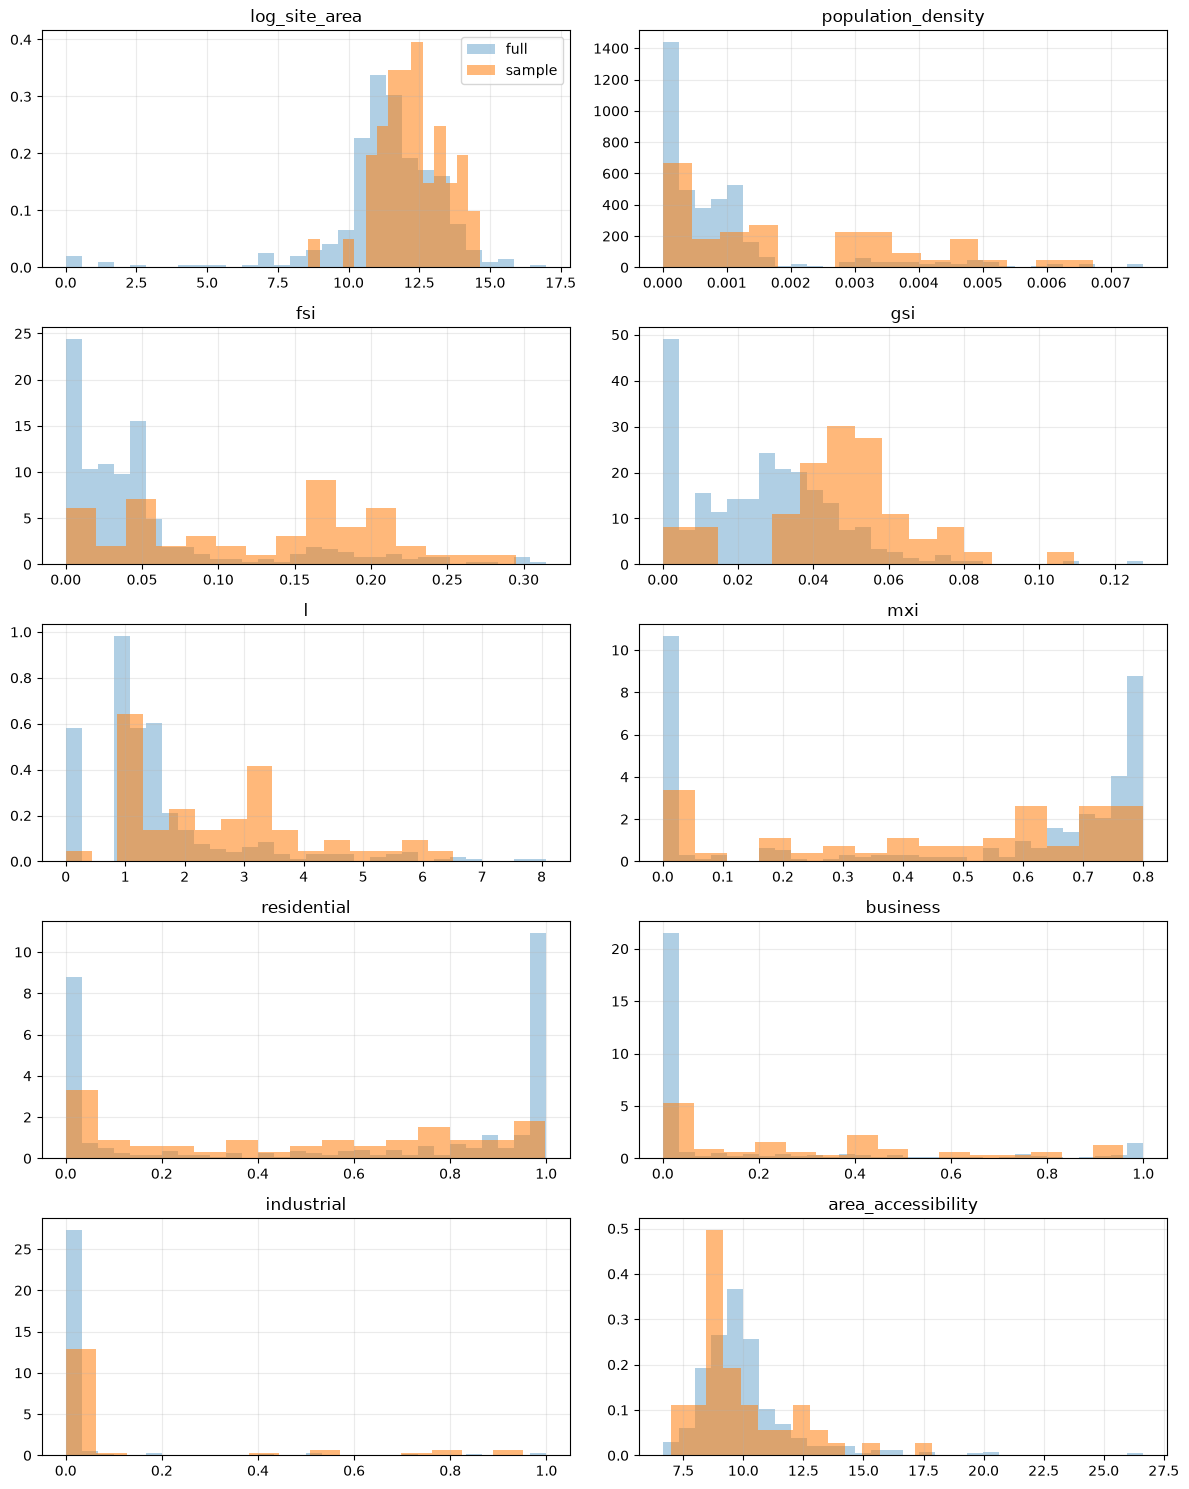

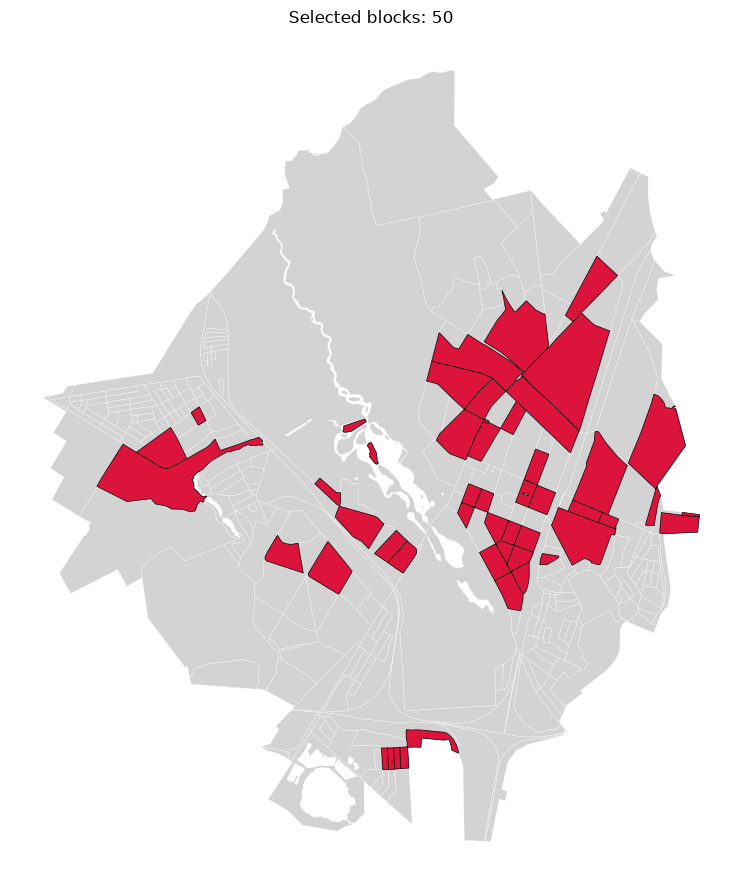

<Axes: title={'center': 'Selected blocks: 50'}>

In [6]:
plot_sampling_diagnostics(full_prepared, sample_prepared, features)
plot_sample_map(full_prepared, sample_gdf)

In [7]:
export_gdf = sample_gdf.loc[:, gdf.columns].copy()
export_gdf.to_file("lhs_icc_sample_50.geojson", driver="GeoJSON")
export_gdf.drop(columns="geometry", errors="ignore").to_csv("lhs_icc_sample_50.csv", index=False)


In [8]:
sample_gdf

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,log_site_area,population_density
18,0.998514,0.000000,0.001174,0.000360,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.998514,22320.362933,...,4.941260e+05,0.211916,0.045171,0.760916,4.691368,mid-rise,10.697344,"POLYGON ((30.06857 59.56932, 30.06907 59.56877...",13.110548,0.005076
272,0.993835,0.000000,0.006165,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.993835,3242.396910,...,5.720920e+04,0.056676,0.056676,0.755595,1.000000,individual residential,12.158884,"POLYGON ((30.1071 59.54098, 30.10712 59.54088,...",10.954487,0.001486
289,0.566852,0.395833,0.035232,0.000000,0.002113,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.566852,51057.261413,...,1.241957e+06,0.184637,0.041110,0.614618,4.491263,mid-rise,11.246269,"POLYGON ((30.12883 59.58497, 30.12965 59.58414...",14.032200,0.003573
210,0.674742,0.325258,0.000000,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.674742,3321.796439,...,9.587870e+04,0.101003,0.034646,0.439415,2.915299,low-rise model,8.528803,"POLYGON ((30.12978 59.55863, 30.1291 59.55925,...",11.470850,0.001408
126,0.249811,0.038483,0.000000,0.711705,0.000000,5.902954e-07,0.0,LandUse.INDUSTRIAL,0.711705,74893.424381,...,9.873976e+05,0.163840,0.075849,0.046046,2.160079,low-rise non-residential,9.752152,"POLYGON ((30.15025 59.56144, 30.14968 59.56148...",13.802829,0.000237
270,0.996399,0.000000,0.003601,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.996399,3055.978423,...,5.851288e+04,0.055298,0.052227,0.755565,1.058798,individual residential,12.563452,"POLYGON ((30.10731 59.5389, 30.10712 59.54088,...",10.977019,0.001350
178,0.599463,0.400537,0.000000,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.599463,7181.454016,...,1.318986e+05,0.187204,0.054447,0.605505,3.438296,low-rise model,8.537552,"POLYGON ((30.13257 59.56236, 30.13252 59.5623,...",11.789796,0.003563
35,0.547847,0.427028,0.000000,0.000000,0.000000,2.512582e-02,0.0,LandUse.RESIDENTIAL,0.547847,11499.978459,...,1.882735e+05,0.210962,0.061081,0.592079,3.453793,low-rise model,9.021528,"POLYGON ((30.1348 59.55978, 30.13463 59.55981,...",12.145656,0.003930
179,0.739963,0.260036,0.000000,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.739963,10573.873547,...,1.933482e+05,0.172937,0.054688,0.570168,3.162238,low-rise model,8.823996,"POLYGON ((30.13013 59.56284, 30.1301 59.56279,...",12.172253,0.003108
87,0.690324,0.219805,0.089872,0.000000,0.000000,0.000000e+00,0.0,LandUse.RESIDENTIAL,0.690324,33119.603537,...,7.050800e+05,0.270308,0.046973,0.693603,5.754552,mid-rise,9.086651,"POLYGON ((30.11452 59.57624, 30.11479 59.57675...",13.466068,0.005901
